In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [3]:
# Generate 200 random X values
# np.random.rand(200,1) → Generates 200 random numbers between 0 and 1
# 6 → Expands the range from (0–1) to (0–6)
# -3 → Shifts the range from (0–6) to (-3–3)
# Final X values are between -3 and 3
X = 6 * np.random.rand(200, 1) - 3


# Generate target (y) values using a quadratic equation
# 0.8 * X**2 → Creates the curve (quadratic effect)
# 0.9 * X → Adds the linear effect (slope)
# +2 → Adds the intercept (shifts the graph upward)
# np.random.randn(200,1) → Adds random noise to make data realistic
# Final equation: y = 0.8x² + 0.9x + 2 + Noise
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1)

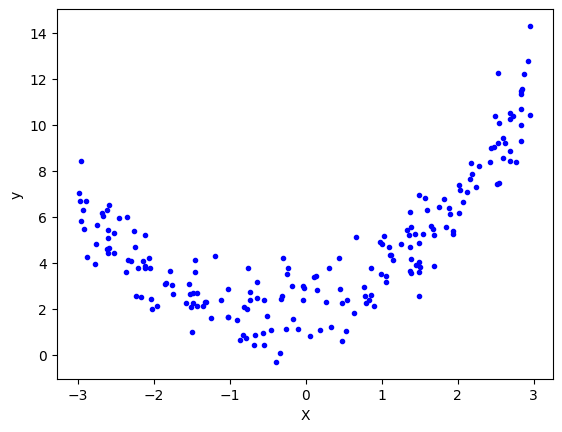

In [4]:
# Plot the generated X and y data as blue dots (scatter plot)
# 'b.' → b = blue color, . = dot marker
plt.plot(X, y, 'b.')

# Label the X-axis
plt.xlabel("X")

# Label the Y-axis
plt.ylabel("y")

# Display the graph on the screen
plt.show()

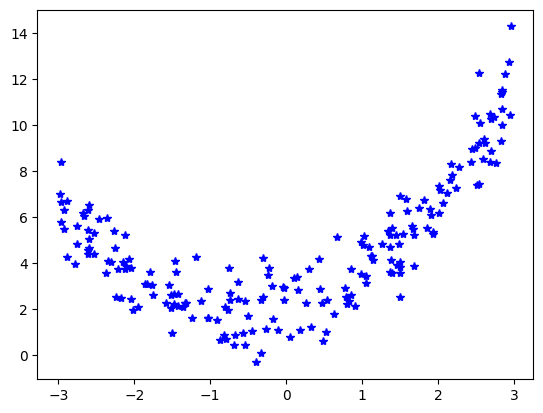

In [5]:
plt.plot(X, y, 'b*')

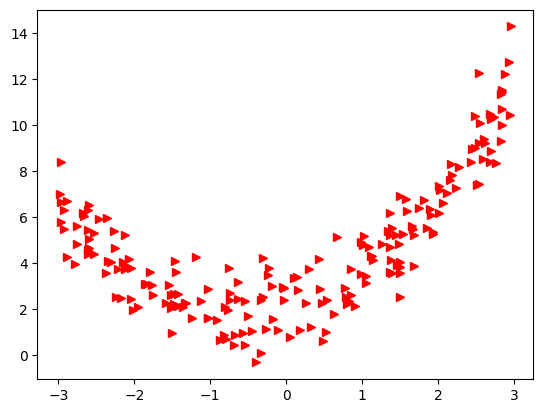

In [6]:
plt.plot(X, y, 'r>')

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y, 
    test_size=0.2,  # 20% of data for testing
    random_state=42  # Ensures reproducibility
)

In [8]:
lr = LinearRegression()

In [9]:
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
y_pred = lr.predict(X_test)
r2_score(y_test, y_pred)

0.328737421032139

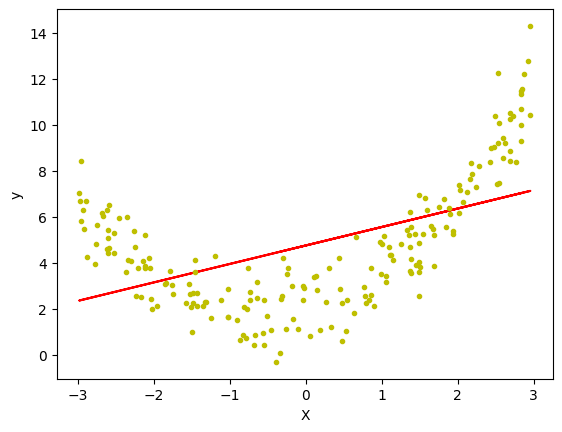

In [11]:
plt.plot(X_train, lr.predict(X_train), color='r')
plt.plot(X, y, 'y.')
plt.xlabel('X')
plt.ylabel('y')
plt.show()


In [12]:
# ============================================
# Apply Polynomial Regression (Degree = 2)
# ============================================

# Create a PolynomialFeatures object
# degree=2 → Creates new features like X²
# include_bias=True → Adds a column of 1s (intercept/bias term)
# Example:
# If X = [2]
# Original Feature      → [2]
# Transformed Features  → [1, 2, 4]
#                        [Bias, X, X²]
# include_bias=True → Adds a column of 1s (intercept/bias term)
poly = PolynomialFeatures(degree=2, include_bias=True)

# Fit on training data and transform it
# Learns the polynomial transformation from X_train
# Example:
# X = [2]
# After transform → [1, 2, 4]
X_train_trans = poly.fit_transform(X_train)

# Transform the test data using the SAME transformation
# Do NOT use fit_transform() on test data
# Because the model should learn only from training data
X_test_trans = poly.transform(X_test)

In [13]:
print(X_train[0])
print(X_train_trans[0])

[-0.32917117]
[ 1.         -0.32917117  0.10835366]


In [14]:
lr = LinearRegression()
lr.fit(X_train_trans, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
y_pred = lr.predict(X_test_trans)

In [16]:
r2_score(y_test, y_pred)

0.8864863389881509

In [17]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.86118932 0.78798979]]
[2.05461875]


In [18]:
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

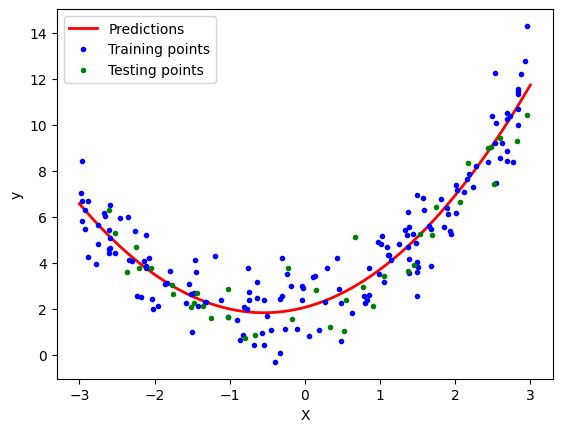

In [20]:
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.", label='Training points')
plt.plot(X_test, y_test, "g.", label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [21]:
def polynomial_regression(degree):
    X_new=np.linspace(-3, 3, 100).reshape(100, 1)
    X_new_poly = poly.transform(X_new)

    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = Pipeline([
            ("poly_features", polybig_features),
            ("std_scaler", std_scaler),
            ("lin_reg", lin_reg),
        ])
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    plt.plot(X_new, y_newbig,'r', label="Degree " + str(degree), linewidth=2)

    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])
    plt.show()

c:\Users\harsh\Desktop\Saloni\ml\.venv\lib\site-packages\sklearn\utils\extmath.py:1163: RuntimeWarning: overflow encountered in square
  temp **= 2
c:\Users\harsh\Desktop\Saloni\ml\.venv\lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


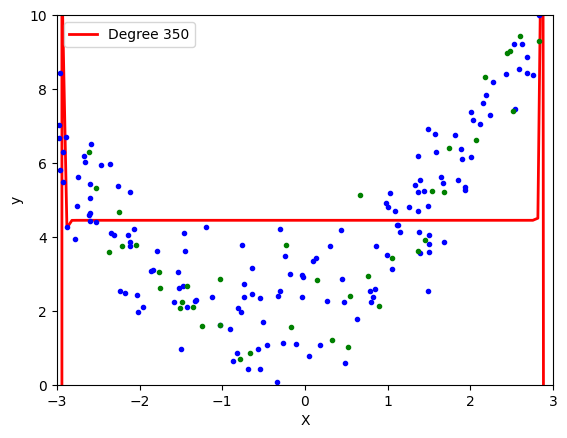

In [22]:
polynomial_regression(350)

In [23]:
poly.powers_

array([[0],
       [1],
       [2]])

c:\Users\harsh\Desktop\Saloni\ml\.venv\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


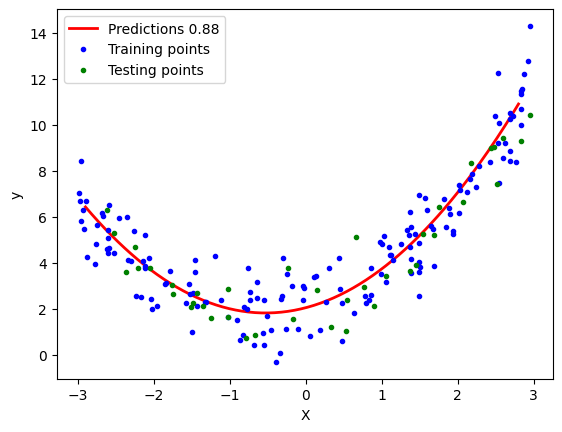

In [24]:
# Applying Gradient Descent

poly = PolynomialFeatures(degree=2)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

sgd = SGDRegressor(max_iter=100)
sgd.fit(X_train_trans,y_train)

X_new=np.linspace(-2.9, 2.8, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = sgd.predict(X_new_poly)

y_pred = sgd.predict(X_test_trans)

plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions " + str(round(r2_score(y_test,y_pred),2)))
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [25]:
# 3D polynomial regression
x = 7 * np.random.rand(100, 1) - 2.8
y = 7 * np.random.rand(100, 1) - 2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y +2 + np.random.randn(100, 1)
# z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2

In [26]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.show()

In [27]:
lr = LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)

x_input = np.linspace(x.min(), x.max(), 10)
y_input = np.linspace(y.min(), y.max(), 10)
xGrid, yGrid = np.meshgrid(x_input,y_input)

final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T

z_final = lr.predict(final).reshape(10,10)

In [28]:
import plotly.graph_objects as go

fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x=x_input, y=y_input, z=z_final))

fig.show()

In [30]:
X_multi = np.array([x, y]).reshape(100, 2)
X_multi.shape

(100, 2)

In [32]:
poly = PolynomialFeatures(degree=30)
X_multi_trans = poly.fit_transform(X_multi)

In [34]:
X_multi_trans.shape

(100, 496)

In [35]:
lr = LinearRegression()
lr.fit(X_multi_trans, z)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [36]:
X_test_multi = poly.transform(final)

In [37]:
z_final = lr.predict(X_multi_trans).reshape(10,10)

In [38]:
fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final))

fig.update_layout(scene = dict(zaxis = dict(range=[0,35])))

fig.show()